<a href="https://colab.research.google.com/github/MyTeachers123/genai-course/blob/main/week2/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 - Diffusion Models: UNet DDPM from Scratch
**COM SCI-X 455 - Week 2**

> Push to `genai-course/week2/lab2.ipynb`. Run on a Colab **T4 GPU** (Runtime -> Change runtime type -> T4 GPU).

Everything is trained from scratch - no pre-trained diffusion weights (the only downloaded weights are the
Inception-v3 network used by FID).

**Fixes applied to the starter code / slides**
1. MNIST is padded from 28x28 to **32x32** so three 2x down-samplings give 32 -> 16 -> 8 -> 4 and the skip
   connections line up (with 28x28 the third level gives 7 -> 3 and `torch.cat` fails on 6x6 vs 7x7).
2. The U-Net starts with a 1 -> 32 convolution, so `GroupNorm(8, ...)` never sees a 1-channel input.
3. Pixels are scaled to **[-1, 1]**, matching the Gaussian noise scale.
4. The DDIM sampler returns the final predicted x0 instead of a still-noisy x at the last step.
5. One `ddpm_sample` / `ddim_sample` signature is used everywhere.
6. Rubric-aligned settings: 30 epochs, Adam lr = 2e-4, batch 128, snapshots at epochs 5/10/15/20/25/30.

## Setup

In [1]:
!pip install pytorch-fid --quiet

In [2]:
import os, time, math, json
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'CPU - switch the runtime to T4 GPU')
SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
os.makedirs('images', exist_ok=True); os.makedirs('checkpoints', exist_ok=True)
RESULTS = {}

EPOCHS = 30           # rubric asks for snapshots up to epoch 30
BATCH = 128
LR = 2e-4
T = 1000
SNAP_EPOCHS = [5, 10, 15, 20, 25, 30]

transform = transforms.Compose([
    transforms.Pad(2),                      # 28x28 -> 32x32 (see fix 1)
    transforms.ToTensor(),                  # [0, 1]
    transforms.Normalize((0.5,), (0.5,)),   # [-1, 1] (see fix 3)
])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
loader = DataLoader(train_data, batch_size=BATCH, shuffle=True, num_workers=2, drop_last=True)
print('Train:', len(train_data), '| image shape:', train_data[0][0].shape)

def to01(x): return ((x.clamp(-1, 1) + 1) / 2).cpu()

def show_grid(imgs, nrow, title=None, path=None, labels=None, scale=1.0):
    imgs = to01(imgs).numpy(); n = len(imgs); nr = math.ceil(n / nrow)
    fig, axes = plt.subplots(nr, nrow, figsize=(nrow * scale, nr * scale + (0.4 if title else 0)))
    for i, ax in enumerate(np.array(axes).reshape(-1)):
        ax.axis('off')
        if i < n:
            ax.imshow(imgs[i, 0], cmap='gray', vmin=0, vmax=1)
            if labels is not None: ax.set_title(labels[i], fontsize=7)
    if title: fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    if path: plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

Device: Tesla T4


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.8MB/s]

Train: 60000 | image shape: torch.Size([1, 32, 32])


## Part 1 - Forward process (noise schedules)
Closed form: **x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps**, eps ~ N(0, I),
alpha_bar_t = prod_{i<=t} (1 - beta_i). No loop over t is needed.

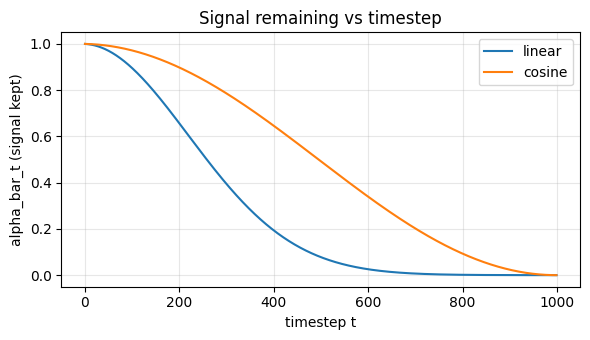

In [3]:
def linear_schedule(T=1000, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T=1000, s=0.008):
    steps = torch.arange(T + 1, dtype=torch.float32)
    f = torch.cos(((steps / T + s) / (1 + s)) * torch.pi / 2) ** 2
    alphas_bar = f / f[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0, 0.999)

class NoiseSchedule:
    """Precomputes everything the forward and reverse processes need."""
    def __init__(self, kind='linear', T=1000, device=DEVICE, **kw):
        self.kind, self.T = kind, T
        betas = linear_schedule(T, **kw) if kind == 'linear' else cosine_schedule(T, **kw)
        self.betas = betas.to(device)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, 0)          # alpha_bar_t

    def q_sample(self, x0, t, noise=None):
        """Forward process x0 -> x_t in one step. Returns (x_t, noise)."""
        if noise is None:
            noise = torch.randn_like(x0)
        ab = self.alphas_cumprod[t].view(-1, 1, 1, 1)
        return ab.sqrt() * x0 + (1 - ab).sqrt() * noise, noise

SCHED = {'linear': NoiseSchedule('linear'), 'cosine': NoiseSchedule('cosine')}

# alpha_bar_t curves: how much of the original signal survives at each step
plt.figure(figsize=(6, 3.5))
for k, s in SCHED.items():
    plt.plot(s.alphas_cumprod.cpu(), label=k)
plt.xlabel('timestep t'); plt.ylabel('alpha_bar_t (signal kept)'); plt.legend(); plt.grid(alpha=.3)
plt.title('Signal remaining vs timestep'); plt.tight_layout(); plt.savefig('images/alpha_bar_curves.png', dpi=150); plt.show()

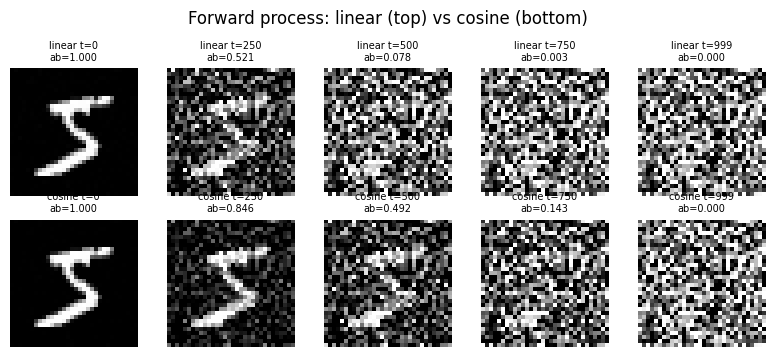

In [4]:
x0 = train_data[0][0].unsqueeze(0).to(DEVICE)
ts = [0, 250, 500, 750, 999]
torch.manual_seed(1); eps = torch.randn_like(x0)           # same noise for both schedules
fig, axes = plt.subplots(2, len(ts), figsize=(len(ts) * 1.6, 3.6))
for r, (k, s) in enumerate(SCHED.items()):
    for c, t in enumerate(ts):
        xt, _ = s.q_sample(x0, torch.tensor([t], device=DEVICE), eps)
        axes[r, c].imshow(to01(xt)[0, 0], cmap='gray', vmin=0, vmax=1); axes[r, c].axis('off')
        axes[r, c].set_title(f'{k} t={t}\nab={s.alphas_cumprod[t]:.3f}', fontsize=7)
plt.suptitle('Forward process: linear (top) vs cosine (bottom)')
plt.tight_layout(); plt.savefig('images/forward_process.png', dpi=150, bbox_inches='tight'); plt.show()

**Which schedule destroys fine detail faster?** *(student answer - look at t=250 and t=500 and at the alpha_bar curves)*

## Part 2 - U-Net noise predictor
Encoder 32 -> 64 -> 128 channels (32x32 -> 16x16 -> 8x8 -> 4x4), bottleneck with self-attention at 4x4,
decoder with skip connections, and the time embedding added inside **every** ResBlock.

In [5]:
class SinusoidalTimeEmb(nn.Module):
    """t -> [sin(t*f_k), cos(t*f_k)] with geometrically spaced frequencies, then an MLP."""
    def __init__(self, dim=128):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim))
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / (half - 1))
        args = t[:, None].float() * freqs[None]
        return self.mlp(torch.cat([torch.sin(args), torch.cos(args)], dim=-1))

class ResBlock(nn.Module):
    """GroupNorm -> SiLU -> Conv, + time bias, GroupNorm -> SiLU -> Conv, + residual."""
    def __init__(self, in_ch, out_ch, time_dim=128):
        super().__init__()
        self.norm1, self.conv1 = nn.GroupNorm(8, in_ch), nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)                 # noise level -> per-channel bias
        self.norm2, self.conv2 = nn.GroupNorm(8, out_ch), nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]             # inject time
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class SelfAttention(nn.Module):
    """Self-attention over the 4x4 = 16 bottleneck positions (cheap because the map is tiny)."""
    def __init__(self, ch, heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.attn = nn.MultiheadAttention(ch, heads, batch_first=True)
    def forward(self, x):
        b, c, h, w = x.shape
        q = self.norm(x).flatten(2).transpose(1, 2)                  # (B, HW, C)
        out, _ = self.attn(q, q, q)
        return x + out.transpose(1, 2).view(b, c, h, w)

class UNet(nn.Module):
    def __init__(self, channels=(32, 64, 128), time_dim=128):
        super().__init__()
        self.time_embed = SinusoidalTimeEmb(time_dim)
        self.init_conv = nn.Conv2d(1, channels[0], 3, padding=1)     # 1 -> 32 channels (see fix 2)
        self.down_blocks, self.downsample = nn.ModuleList(), nn.ModuleList()
        ch_in = channels[0]
        for ch in channels:                                          # encoder: ResBlock + downsample
            self.down_blocks.append(ResBlock(ch_in, ch, time_dim))
            self.downsample.append(nn.Conv2d(ch, ch, 4, 2, 1))        # halve H and W
            ch_in = ch
        mid = channels[-1] * 2
        self.mid1 = ResBlock(ch_in, mid, time_dim)                   # bottleneck at 4x4
        self.mid_attn = SelfAttention(mid)
        self.mid2 = ResBlock(mid, mid, time_dim)
        self.upsample, self.up_blocks = nn.ModuleList(), nn.ModuleList()
        ch_in = mid
        for ch in reversed(channels):                                # decoder: upsample + skip + ResBlock
            self.upsample.append(nn.ConvTranspose2d(ch_in, ch_in, 4, 2, 1))
            self.up_blocks.append(ResBlock(ch_in + ch, ch, time_dim))  # + ch from the skip connection
            ch_in = ch
        self.out = nn.Sequential(nn.GroupNorm(8, channels[0]), nn.SiLU(), nn.Conv2d(channels[0], 1, 3, padding=1))

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        x = self.init_conv(x)
        skips = []
        for block, down in zip(self.down_blocks, self.downsample):
            x = block(x, t_emb); skips.append(x)                     # keep full-resolution features
            x = down(x)
        x = self.mid2(self.mid_attn(self.mid1(x, t_emb)), t_emb)
        for up, block, skip in zip(self.upsample, self.up_blocks, reversed(skips)):
            x = up(x)
            x = block(torch.cat([x, skip], dim=1), t_emb)            # paste the skip connection
        return self.out(x)                                           # predicted noise eps_theta

m = UNet().to(DEVICE)
print('Parameters:', sum(p.numel() for p in m.parameters()))
with torch.no_grad():
    print('Shape check:', m(torch.randn(2, 1, 32, 32, device=DEVICE), torch.tensor([0, 999], device=DEVICE)).shape)
del m

Parameters: 5488737
Shape check: torch.Size([2, 1, 32, 32])


## Samplers (defined before training so we can watch generation improve)
* **DDPM** - 1000 stochastic steps, sigma_t^2 = beta_t.
* **DDIM** - deterministic when eta = 0, skips timesteps, works on the *same* trained model.

In [6]:
@torch.no_grad()
def ddpm_sample(model, sched, x_T):
    """x_T: starting noise (B,1,32,32). Returns x_0 in [-1, 1]."""
    model.eval(); x = x_T.clone()
    for t in reversed(range(sched.T)):
        tt = torch.full((x.size(0),), t, device=x.device, dtype=torch.long)
        eps = model(x, tt)
        beta, alpha, ab = sched.betas[t], sched.alphas[t], sched.alphas_cumprod[t]
        x = (x - beta / (1 - ab).sqrt() * eps) / alpha.sqrt()        # posterior mean
        if t > 0:
            x = x + beta.sqrt() * torch.randn_like(x)
    return x.clamp(-1, 1)

@torch.no_grad()
def ddim_sample(model, sched, x_T, n_steps=50, eta=0.0):
    """eta = 0: deterministic (same x_T -> same image). eta = 1: DDPM-like stochasticity."""
    model.eval(); x = x_T.clone()
    ts = torch.linspace(sched.T - 1, 0, n_steps).round().long().tolist()
    for i, t in enumerate(ts):
        tt = torch.full((x.size(0),), t, device=x.device, dtype=torch.long)
        ab = sched.alphas_cumprod[t]
        eps = model(x, tt)
        x0 = ((x - (1 - ab).sqrt() * eps) / ab.sqrt()).clamp(-1, 1)  # predicted clean image
        if i == len(ts) - 1:
            return x0                                                # last step: return x0 (see fix 4)
        ab_next = sched.alphas_cumprod[ts[i + 1]]
        sigma = eta * ((1 - ab_next) / (1 - ab) * (1 - ab / ab_next)).sqrt()
        eps_dir = (1 - ab_next - sigma ** 2).clamp(min=0).sqrt() * eps
        x = ab_next.sqrt() * x0 + eps_dir + sigma * torch.randn_like(x)
    return x

## Part 3 - Training (both schedules, same architecture, same seed)
Loss = MSE between the true noise and the predicted noise. Every 5 epochs a 4x4 grid is sampled with
**DDPM-1000** from the same fixed noise. Checkpoints are saved, so if Colab disconnects, re-running this cell
continues from the last finished epoch.

In [7]:
FIXED_NOISE = torch.randn(16, 1, 32, 32, generator=torch.Generator().manual_seed(123)).to(DEVICE)

def train_ddpm(kind, epochs=EPOCHS):
    sched = SCHED[kind]
    torch.manual_seed(SEED)
    model = UNet().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    ckpt = f'checkpoints/unet_{kind}.pt'
    state = {'epoch': 0, 'losses': [], 'snaps': {}, 'time': 0.0}
    if os.path.exists(ckpt):
        saved = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        model.load_state_dict(saved['model']); opt.load_state_dict(saved['opt']); state = saved['state']
        print(f'[{kind}] resuming from epoch {state["epoch"]}')
    for epoch in range(state['epoch'] + 1, epochs + 1):
        model.train(); t0 = time.time(); total = 0.0
        for x0, _ in loader:
            x0 = x0.to(DEVICE)
            t = torch.randint(0, sched.T, (x0.size(0),), device=DEVICE)   # random timestep per image
            xt, noise = sched.q_sample(x0, t)                             # noisy image + true noise
            loss = F.mse_loss(model(xt, t), noise)                        # the entire objective
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)             # guards against NaN spikes
            opt.step(); total += loss.item()
        state['time'] += time.time() - t0
        state['losses'].append(total / len(loader)); state['epoch'] = epoch
        msg = f'[{kind}] epoch {epoch:2d} | loss {state["losses"][-1]:.4f} | {state["time"]/60:5.1f} min'
        if epoch in SNAP_EPOCHS:
            state['snaps'][epoch] = ddpm_sample(model, sched, FIXED_NOISE).cpu()
            msg += ' | snapshot saved'
        print(msg)
        torch.save({'model': model.state_dict(), 'opt': opt.state_dict(), 'state': state}, ckpt)
    return model, state

MODELS, STATES = {}, {}
for kind in ['linear', 'cosine']:
    MODELS[kind], STATES[kind] = train_ddpm(kind)
RESULTS['train_minutes'] = {k: round(s['time'] / 60, 1) for k, s in STATES.items()}
RESULTS['final_loss'] = {k: s['losses'][-1] for k, s in STATES.items()}

[linear] epoch  1 | loss 0.0656 |   1.0 min
[linear] epoch  2 | loss 0.0270 |   2.1 min
[linear] epoch  3 | loss 0.0237 |   3.2 min
[linear] epoch  4 | loss 0.0217 |   4.3 min
[linear] epoch  5 | loss 0.0210 |   5.3 min | snapshot saved
[linear] epoch  6 | loss 0.0204 |   6.4 min
[linear] epoch  7 | loss 0.0195 |   7.5 min
[linear] epoch  8 | loss 0.0195 |   8.6 min
[linear] epoch  9 | loss 0.0192 |   9.7 min
[linear] epoch 10 | loss 0.0189 |  10.8 min | snapshot saved
[linear] epoch 11 | loss 0.0186 |  11.9 min
[linear] epoch 12 | loss 0.0184 |  13.0 min
[linear] epoch 13 | loss 0.0183 |  14.1 min
[linear] epoch 14 | loss 0.0183 |  15.2 min
[linear] epoch 15 | loss 0.0181 |  16.3 min | snapshot saved
[linear] epoch 16 | loss 0.0180 |  17.4 min
[linear] epoch 17 | loss 0.0180 |  18.5 min
[linear] epoch 18 | loss 0.0178 |  19.6 min
[linear] epoch 19 | loss 0.0178 |  20.6 min
[linear] epoch 20 | loss 0.0177 |  21.7 min | snapshot saved
[linear] epoch 21 | loss 0.0176 |  22.8 min
[linear]

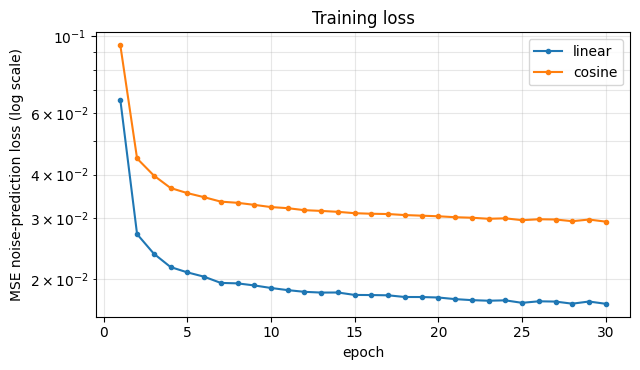

{'linear': [0.0656, 0.027, 0.0237, 0.0217, 0.021, 0.0204, 0.0195, 0.0195, 0.0192, 0.0189, 0.0186, 0.0184, 0.0183, 0.0183, 0.0181, 0.018, 0.018, 0.0178, 0.0178, 0.0177, 0.0176, 0.0174, 0.0174, 0.0174, 0.0171, 0.0173, 0.0173, 0.017, 0.0173, 0.017], 'cosine': [0.0941, 0.0445, 0.0398, 0.0366, 0.0354, 0.0345, 0.0335, 0.0332, 0.0328, 0.0323, 0.032, 0.0316, 0.0315, 0.0313, 0.031, 0.0309, 0.0308, 0.0306, 0.0305, 0.0304, 0.0302, 0.0301, 0.0299, 0.03, 0.0296, 0.0298, 0.0297, 0.0294, 0.0297, 0.0293]}


In [8]:
plt.figure(figsize=(6.5, 3.8))
for k, s in STATES.items():
    plt.plot(range(1, len(s['losses']) + 1), s['losses'], marker='o', ms=3, label=k)
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE noise-prediction loss (log scale)')
plt.title('Training loss'); plt.legend(); plt.grid(alpha=.3, which='both'); plt.tight_layout()
plt.savefig('images/loss_curve.png', dpi=150); plt.show()
print({k: [round(v, 4) for v in s['losses']] for k, s in STATES.items()})

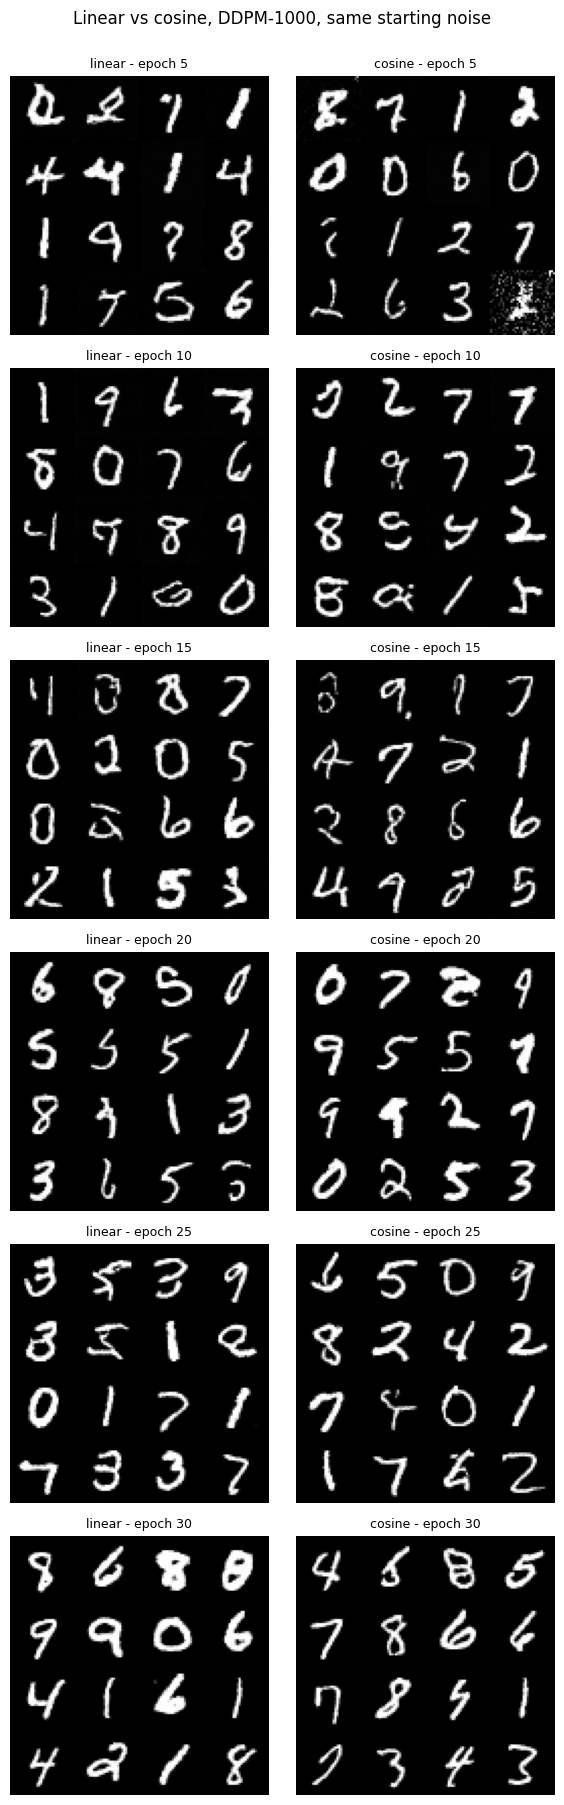

In [9]:
# Schedule comparison grid: rows = epochs, left = linear, right = cosine (same fixed noise)
eps_shown = [e for e in SNAP_EPOCHS if e in STATES['linear']['snaps']]
fig, axes = plt.subplots(len(eps_shown), 2, figsize=(6, 3 * len(eps_shown)))
axes = np.atleast_2d(axes)
for r, e in enumerate(eps_shown):
    for c, k in enumerate(['linear', 'cosine']):
        g = to01(STATES[k]['snaps'][e]).view(4, 4, 32, 32).permute(0, 2, 1, 3).reshape(128, 128)
        axes[r, c].imshow(g, cmap='gray', vmin=0, vmax=1); axes[r, c].axis('off')
        axes[r, c].set_title(f'{k} - epoch {e}', fontsize=9)
plt.suptitle('Linear vs cosine, DDPM-1000, same starting noise', y=1.0)
plt.tight_layout(); plt.savefig('images/schedule_comparison.png', dpi=130, bbox_inches='tight'); plt.show()

**One-line quality note per epoch** *(student)*

| Epoch | Linear | Cosine |
|---|---|---|
| 5 | | |
| 10 | | |
| 20 | | |
| 30 | | |

## Part 4 - DDIM vs DDPM: speed and quality
Same trained model (cosine), same starting noise, 100 samples per setting.

Sampler       seconds / 100 imgs  ms / img  speed-up
DDPM-1000                  44.37     443.7      1.0x
DDIM-50                     2.23      22.3     19.9x
DDIM-20                     0.89       8.9     50.0x
DDIM-10                     0.44       4.4     99.8x
DDIM-5                      0.22       2.2    199.9x


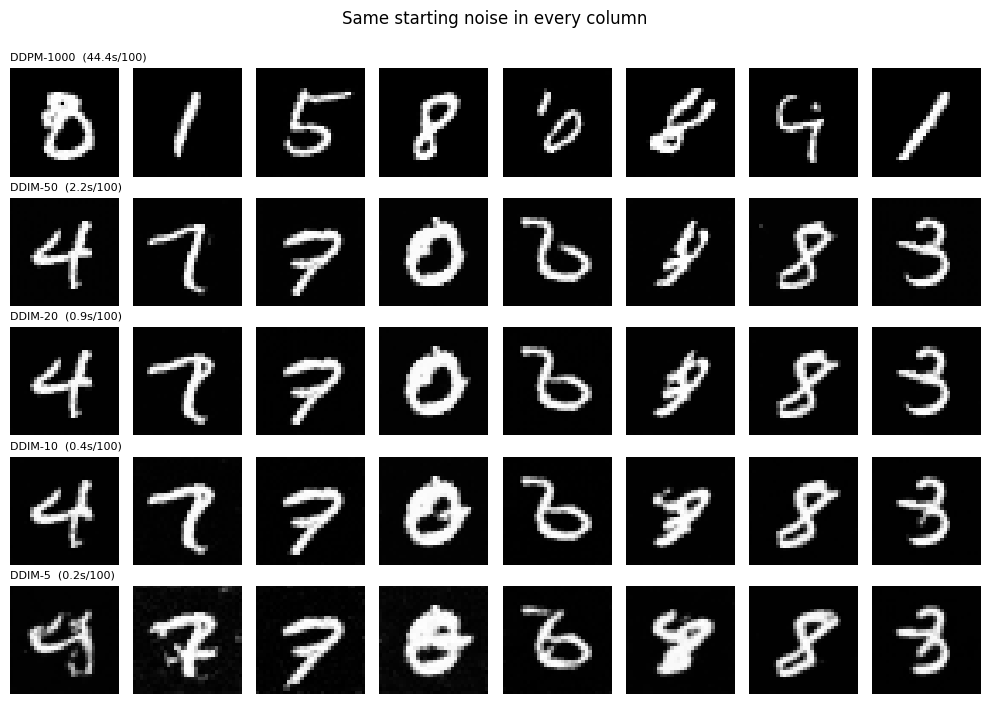

In [10]:
def timed(fn, *a, **kw):
    if DEVICE == 'cuda': torch.cuda.synchronize()
    t0 = time.time(); out = fn(*a, **kw)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    return out, time.time() - t0

model, sched = MODELS['cosine'], SCHED['cosine']
x_T = torch.randn(100, 1, 32, 32, generator=torch.Generator().manual_seed(7)).to(DEVICE)
settings = [('DDPM', 1000), ('DDIM', 50), ('DDIM', 20), ('DDIM', 10), ('DDIM', 5)]
outs, timing = {}, {}
for name, n in settings:
    fn = (lambda: ddpm_sample(model, sched, x_T)) if name == 'DDPM' else (lambda n=n: ddim_sample(model, sched, x_T, n))
    outs[(name, n)], timing[f'{name}-{n}'] = timed(fn)
base = timing['DDPM-1000']
print(f"{'Sampler':<12}{'seconds / 100 imgs':>20}{'ms / img':>10}{'speed-up':>10}")
for k, v in timing.items():
    print(f'{k:<12}{v:20.2f}{v * 10:10.1f}{base / v:9.1f}x')
RESULTS['timing_seconds_per_100'] = timing

fig, axes = plt.subplots(len(settings), 8, figsize=(10, 1.4 * len(settings)))
for r, (name, n) in enumerate(settings):
    for c in range(8):
        axes[r, c].imshow(to01(outs[(name, n)][c])[0], cmap='gray', vmin=0, vmax=1); axes[r, c].axis('off')
    axes[r, 0].set_title(f'{name}-{n}  ({timing[f"{name}-{n}"]:.1f}s/100)', fontsize=8, loc='left')
plt.suptitle('Same starting noise in every column', y=1.0)
plt.tight_layout(); plt.savefig('images/ddim_vs_ddpm.png', dpi=150, bbox_inches='tight'); plt.show()

eta=0, two runs, max pixel difference: 0.00031563639640808105
eta=1, two runs, max pixel difference: 1.9968717098236084


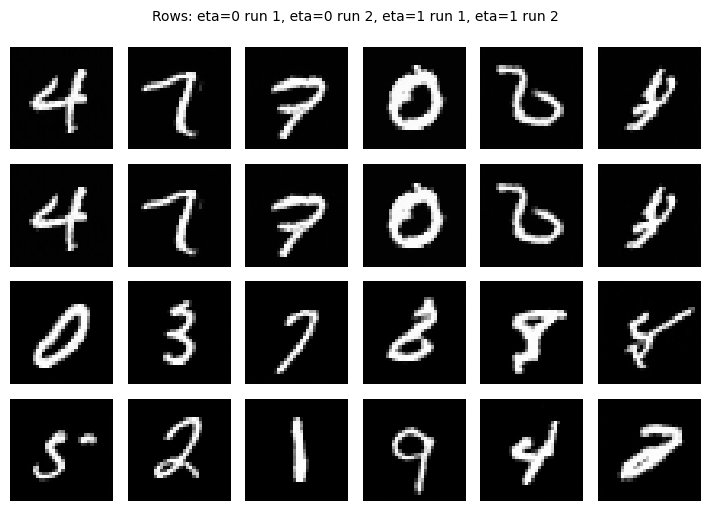

In [11]:
# Determinism check (useful for reflection Q4)
small = x_T[:6]
a = ddim_sample(model, sched, small, 50, eta=0.0); b = ddim_sample(model, sched, small, 50, eta=0.0)
c = ddim_sample(model, sched, small, 50, eta=1.0); d = ddim_sample(model, sched, small, 50, eta=1.0)
print('eta=0, two runs, max pixel difference:', (a - b).abs().max().item())
print('eta=1, two runs, max pixel difference:', (c - d).abs().max().item())
show_grid(torch.cat([a, b, c, d]), nrow=6, title='Rows: eta=0 run 1, eta=0 run 2, eta=1 run 1, eta=1 run 2',
          path='images/ddim_determinism.png', scale=1.2)

## FID table
1,000 generated samples vs 1,000 real MNIST **test** images (both 32x32, Inception-v3 features via pytorch-fid).
A real-vs-real score is included as the practical floor at this sample size.

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 110MB/s]


Real train vs real test (floor)      15.86
Linear - DDPM-1000                   17.35
Cosine - DDPM-1000                   16.48
Cosine - DDIM-50                     21.11
Cosine - DDIM-20                     23.73
Cosine - DDIM-5                      73.09


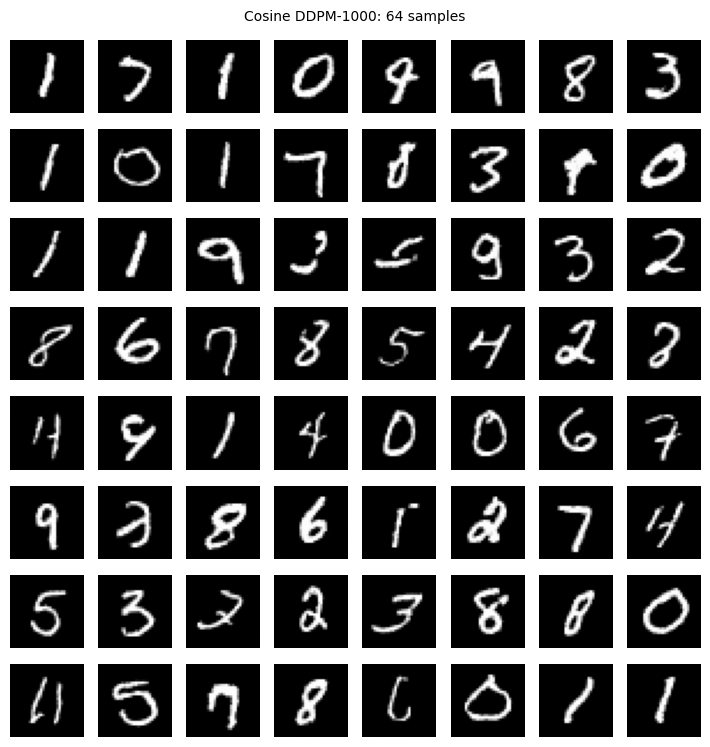

In [12]:
from pytorch_fid.inception import InceptionV3
from pytorch_fid.fid_score import calculate_frechet_distance
inception = InceptionV3([InceptionV3.BLOCK_INDEX_BY_DIM[2048]]).to(DEVICE).eval()

@torch.no_grad()
def stats(imgs01, bs=100):
    f = np.concatenate([inception(imgs01[i:i+bs].to(DEVICE).repeat(1, 3, 1, 1))[0].flatten(1).cpu().numpy()
                        for i in range(0, len(imgs01), bs)])
    return f.mean(0), np.cov(f, rowvar=False)

N = 1000
real_test = torch.stack([test_data[i][0] for i in range(N)])
real_train = torch.stack([train_data[i][0] for i in range(N)])
mu_r, sig_r = stats(to01(real_test))
def fid(x): mu, sig = stats(to01(x)); return float(calculate_frechet_distance(mu, sig, mu_r, sig_r))

@torch.no_grad()
def generate(fn, n=N, bs=500, seed=11):
    g = torch.Generator().manual_seed(seed)
    return torch.cat([fn(torch.randn(bs, 1, 32, 32, generator=g).to(DEVICE)) for _ in range(n // bs)]).cpu()

fids = {'Real train vs real test (floor)': fid(real_train)}
fids['Linear - DDPM-1000'] = fid(generate(lambda z: ddpm_sample(MODELS['linear'], SCHED['linear'], z)))
cos_ddpm = generate(lambda z: ddpm_sample(MODELS['cosine'], SCHED['cosine'], z))
fids['Cosine - DDPM-1000'] = fid(cos_ddpm)
for n in [50, 20, 5]:
    fids[f'Cosine - DDIM-{n}'] = fid(generate(lambda z, n=n: ddim_sample(MODELS['cosine'], SCHED['cosine'], z, n)))
RESULTS['fid'] = fids
for k, v in fids.items():
    print(f'{k:<34}{v:8.2f}')
show_grid(cos_ddpm[:64], nrow=8, title='Cosine DDPM-1000: 64 samples', path='images/cosine_ddpm_64.png', scale=0.9)

### Deliverable tables (student fills in the interpretation / ratings)

**FID table** - one sentence per row interpreting the number.

| Setting | FID | Interpretation (student) |
|---|---|---|
| Linear - DDPM-1000 | see output | |
| Cosine - DDPM-1000 | see output | |
| Cosine - DDIM-50 | see output | |
| Cosine - DDPM-1000 vs DDIM-50 difference | see output | |

**DDIM timing table**

| Steps | Wall-clock (s / 100 images) | Visual quality 1-5 (student) |
|---|---|---|
| 1000 (DDPM) | see output | |
| 50 | see output | |
| 20 | see output | |
| 5 | see output | |

**Minimum viable step count for my use case** *(student)*: ...

In [13]:
with open('results.json', 'w') as f:
    json.dump(RESULTS, f, indent=2)
print(json.dumps(RESULTS, indent=2))

{
  "train_minutes": {
    "linear": 32.7,
    "cosine": 32.7
  },
  "final_loss": {
    "linear": 0.017025494414708044,
    "cosine": 0.029311110010832295
  },
  "timing_seconds_per_100": {
    "DDPM-1000": 44.37190890312195,
    "DDIM-50": 2.2302277088165283,
    "DDIM-20": 0.8881533145904541,
    "DDIM-10": 0.44442057609558105,
    "DDIM-5": 0.22194457054138184
  },
  "fid": {
    "Real train vs real test (floor)": 15.858155231063876,
    "Linear - DDPM-1000": 17.348327391491353,
    "Cosine - DDPM-1000": 16.484506163022388,
    "Cosine - DDIM-50": 21.10810836279765,
    "Cosine - DDIM-20": 23.726961649223995,
    "Cosine - DDIM-5": 73.08965521925279
  }
}


### Reflect *(student - answer in your own words)*
1. Did the cosine schedule produce better results than linear at 20 epochs? What visual difference did you see?
2. How much faster was DDIM vs DDPM? Was the quality difference acceptable for your use case?
3. Why does DDIM produce the same output every run given the same starting noise?

The four graded production questions go in `reflection.md`.

---
## Submission
- [ ] Push to `genai-course/week2/lab2.ipynb` (plus `images/`, `results.json`, `reflection.md`)
- [ ] Loss curve plotted
- [ ] Schedule comparison visualised
- [ ] DDIM vs DDPM timing + quality comparison